### NEEDLE 1.0 feature map for plotting in paper

(4547, 26)


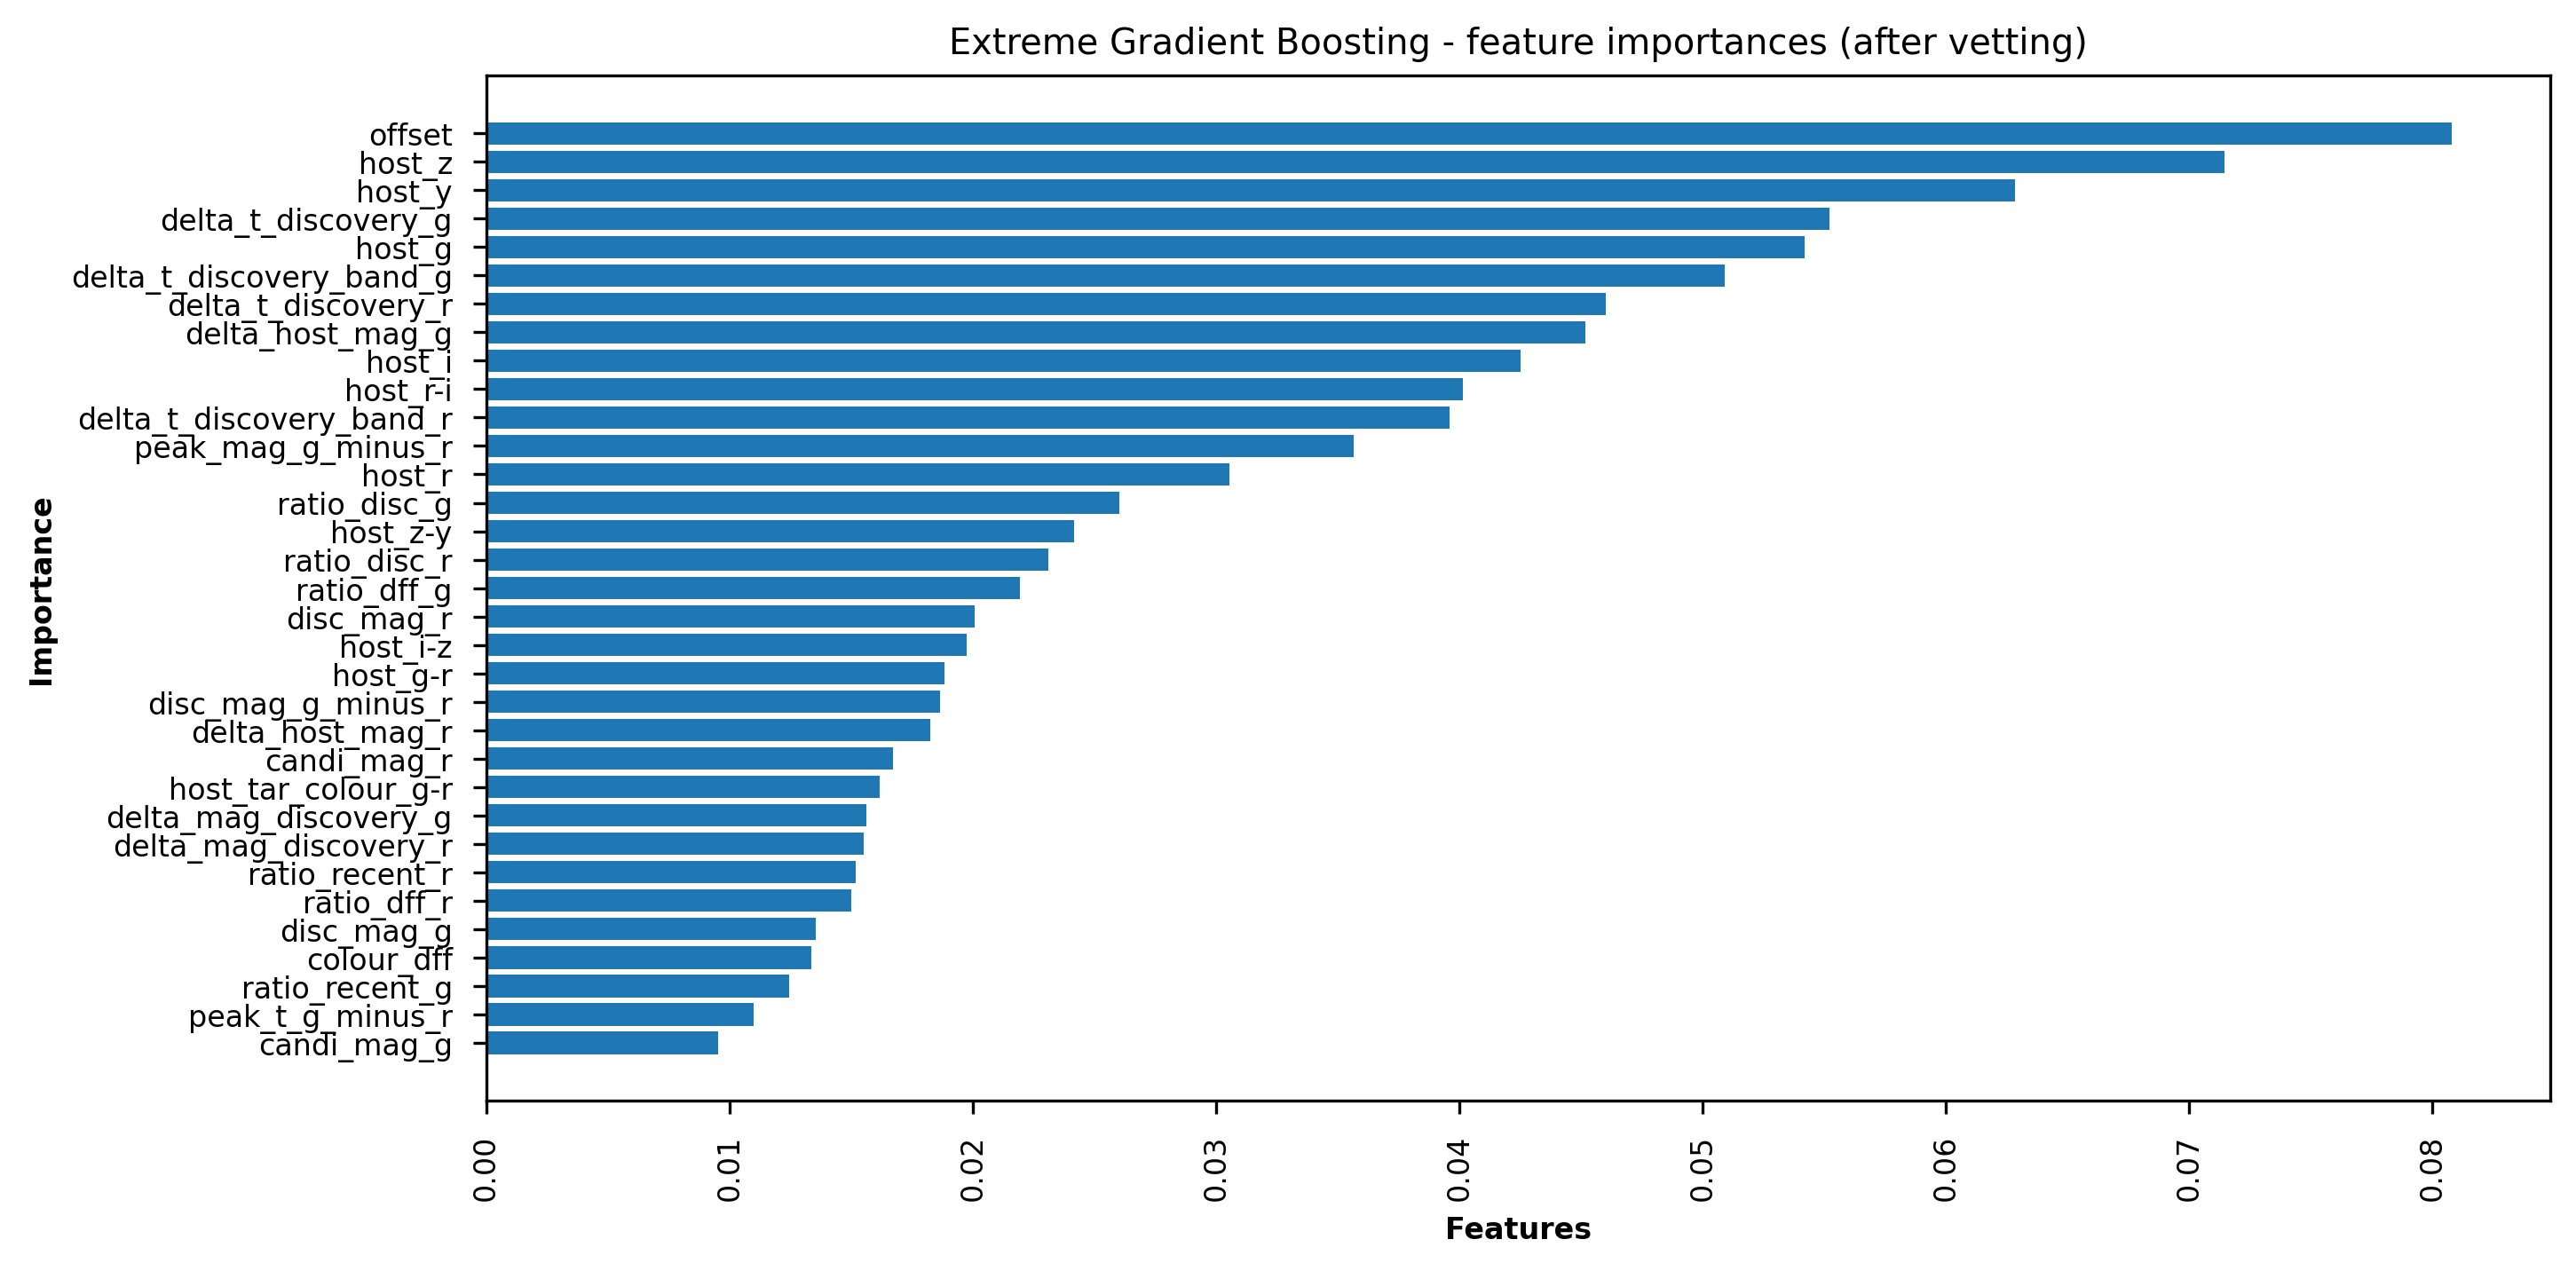

In [4]:
from preprocessing import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from config import *





data_path = '/Users/xinyuesheng/Documents/astro_projects/scripts/NEEDLE2.0/needle_train/k_fold_sets/hosted_set/full_set_original.hdf5'
model_path = '../models/feature_upgrade/'
output_path = model_path+'20250624'
scaling_data_path =  None #'../info/global_scaling_data.json'
normalize_method = 1
threshold = 0.5

# label_path = '../info/label_dict_equal_test.json'
# label_dict = open(label_path,'r')
# label_dict = json.loads(label_dict.read())


if not os.path.exists(model_path):
    os.makedirs(model_path)
if not os.path.exists(output_path):
    os.makedirs(output_path)

np.random.seed(None)
train_imageset, train_metaset, train_labels, _,_,_, feature_importances = preprocessing(data_path, RAW_LABEL_DICT, model_path, normalize_method = normalize_method, scaling_data_path = scaling_data_path, feature_ranking_path = None, has_host = True, split_ratio = 0)
# valid_imageset, valid_metaset, valid_labels, _ = preprocessing_untouched(valid_path, RAW_LABEL_DICT, model_path, normalize_method = normalize_method, scaling_data_path = scaling_data_path, has_host = True)


{0, 1, 2}


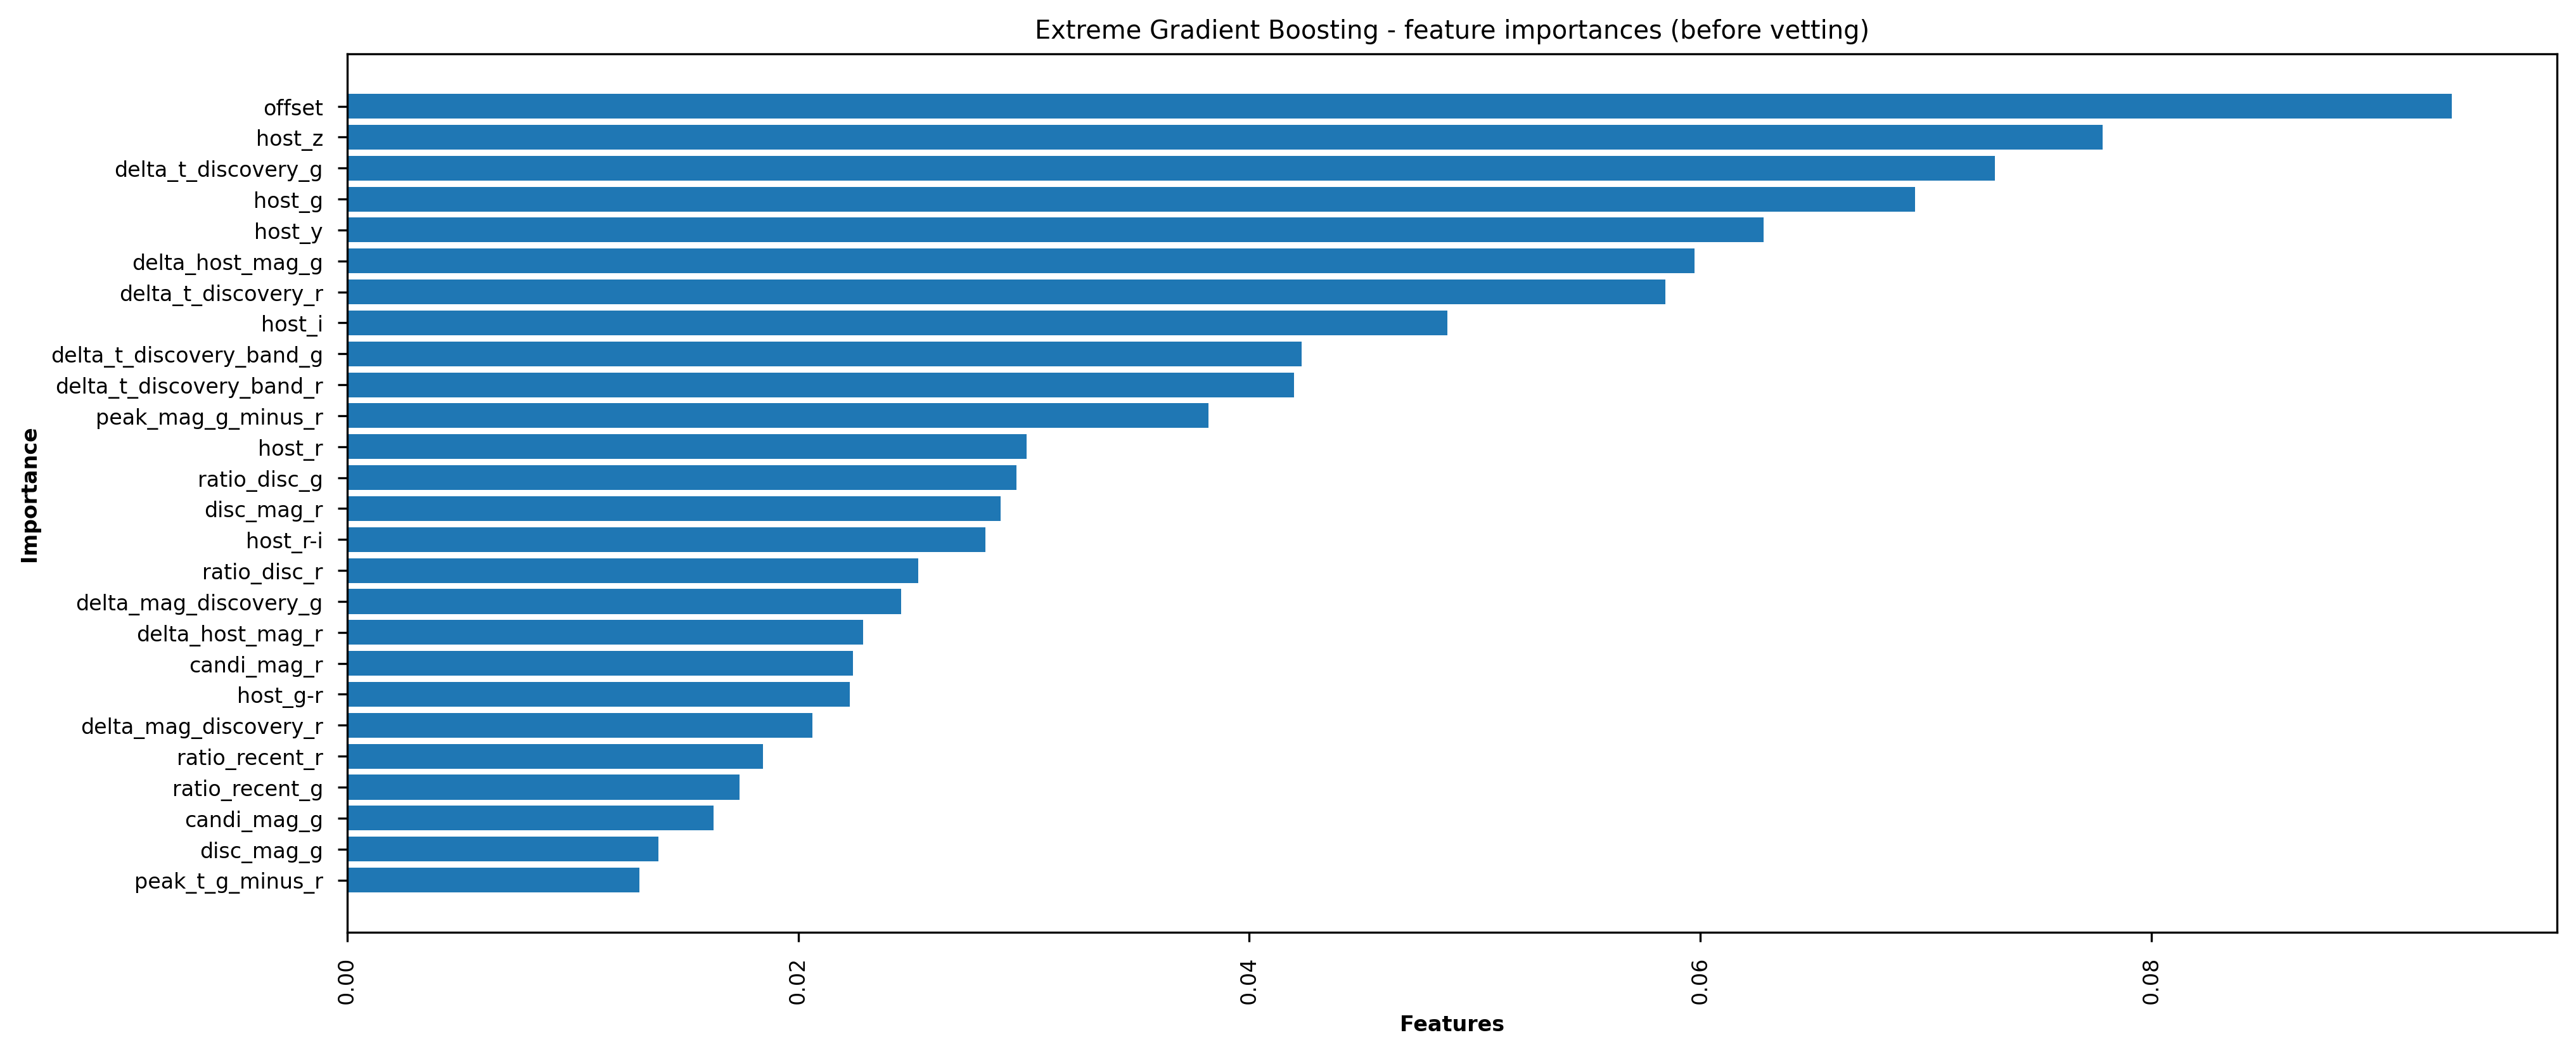

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from preprocessing import open_with_h5py, preprocessing
import json


filepath = '/Users/xinyuesheng/Documents/astro_projects/scripts/NEEDLE2.0/needle_train/k_fold_sets/hosted_set/full_set_original.hdf5'

label_path = '../info/label_dict_equal_test.json'
label_dict = open(label_path,'r')
label_dict = json.loads(label_dict.read())

# Load the Iris dataset - replace with light curve features
imageset, labels, metaset, idx_set = open_with_h5py(filepath)


X = np.nan_to_num(metaset)
y = labels

print(set(y))
class_weight = {}
for i in np.arange(len(set(labels.flatten()))):
    class_weight[i] = labels.shape[0]/len(np.where(labels.flatten()==i)[0])


import xgboost as xgb
from xgboost import plot_importance
feature_names = ['candi_mag_r', 'disc_mag_r', 'delta_mag_discovery_r', 'delta_t_discovery_band_r', 'delta_t_discovery_r', 'ratio_recent_r', 'ratio_disc_r', 'delta_host_mag_r',
                 'candi_mag_g', 'disc_mag_g', 'delta_mag_discovery_g', 'delta_t_discovery_band_g', 'delta_t_discovery_g', 'ratio_recent_g', 'ratio_disc_g', 'delta_host_mag_g',
                  'peak_mag_g_minus_r', 'peak_t_g_minus_r', 
                  'host_g','host_r','host_i','host_z','host_y', 'host_g-r', 'host_r-i', 
                  'offset']
best_xgb_params = {'subsample': 0.8, 'n_estimators': 200, 'min_child_weight': 2, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 0.6}
xgb_model= xgb.XGBClassifier(**best_xgb_params)
sample_weights = np.array([class_weight[cls] for cls in y])
xgb_model.fit(X, labels, sample_weight=sample_weights)
importances = xgb_model.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=True)
plt.figure(figsize=(15, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Extreme Gradient Boosting - feature importances (before vetting)')
plt.xticks(rotation=90)
plt.show()


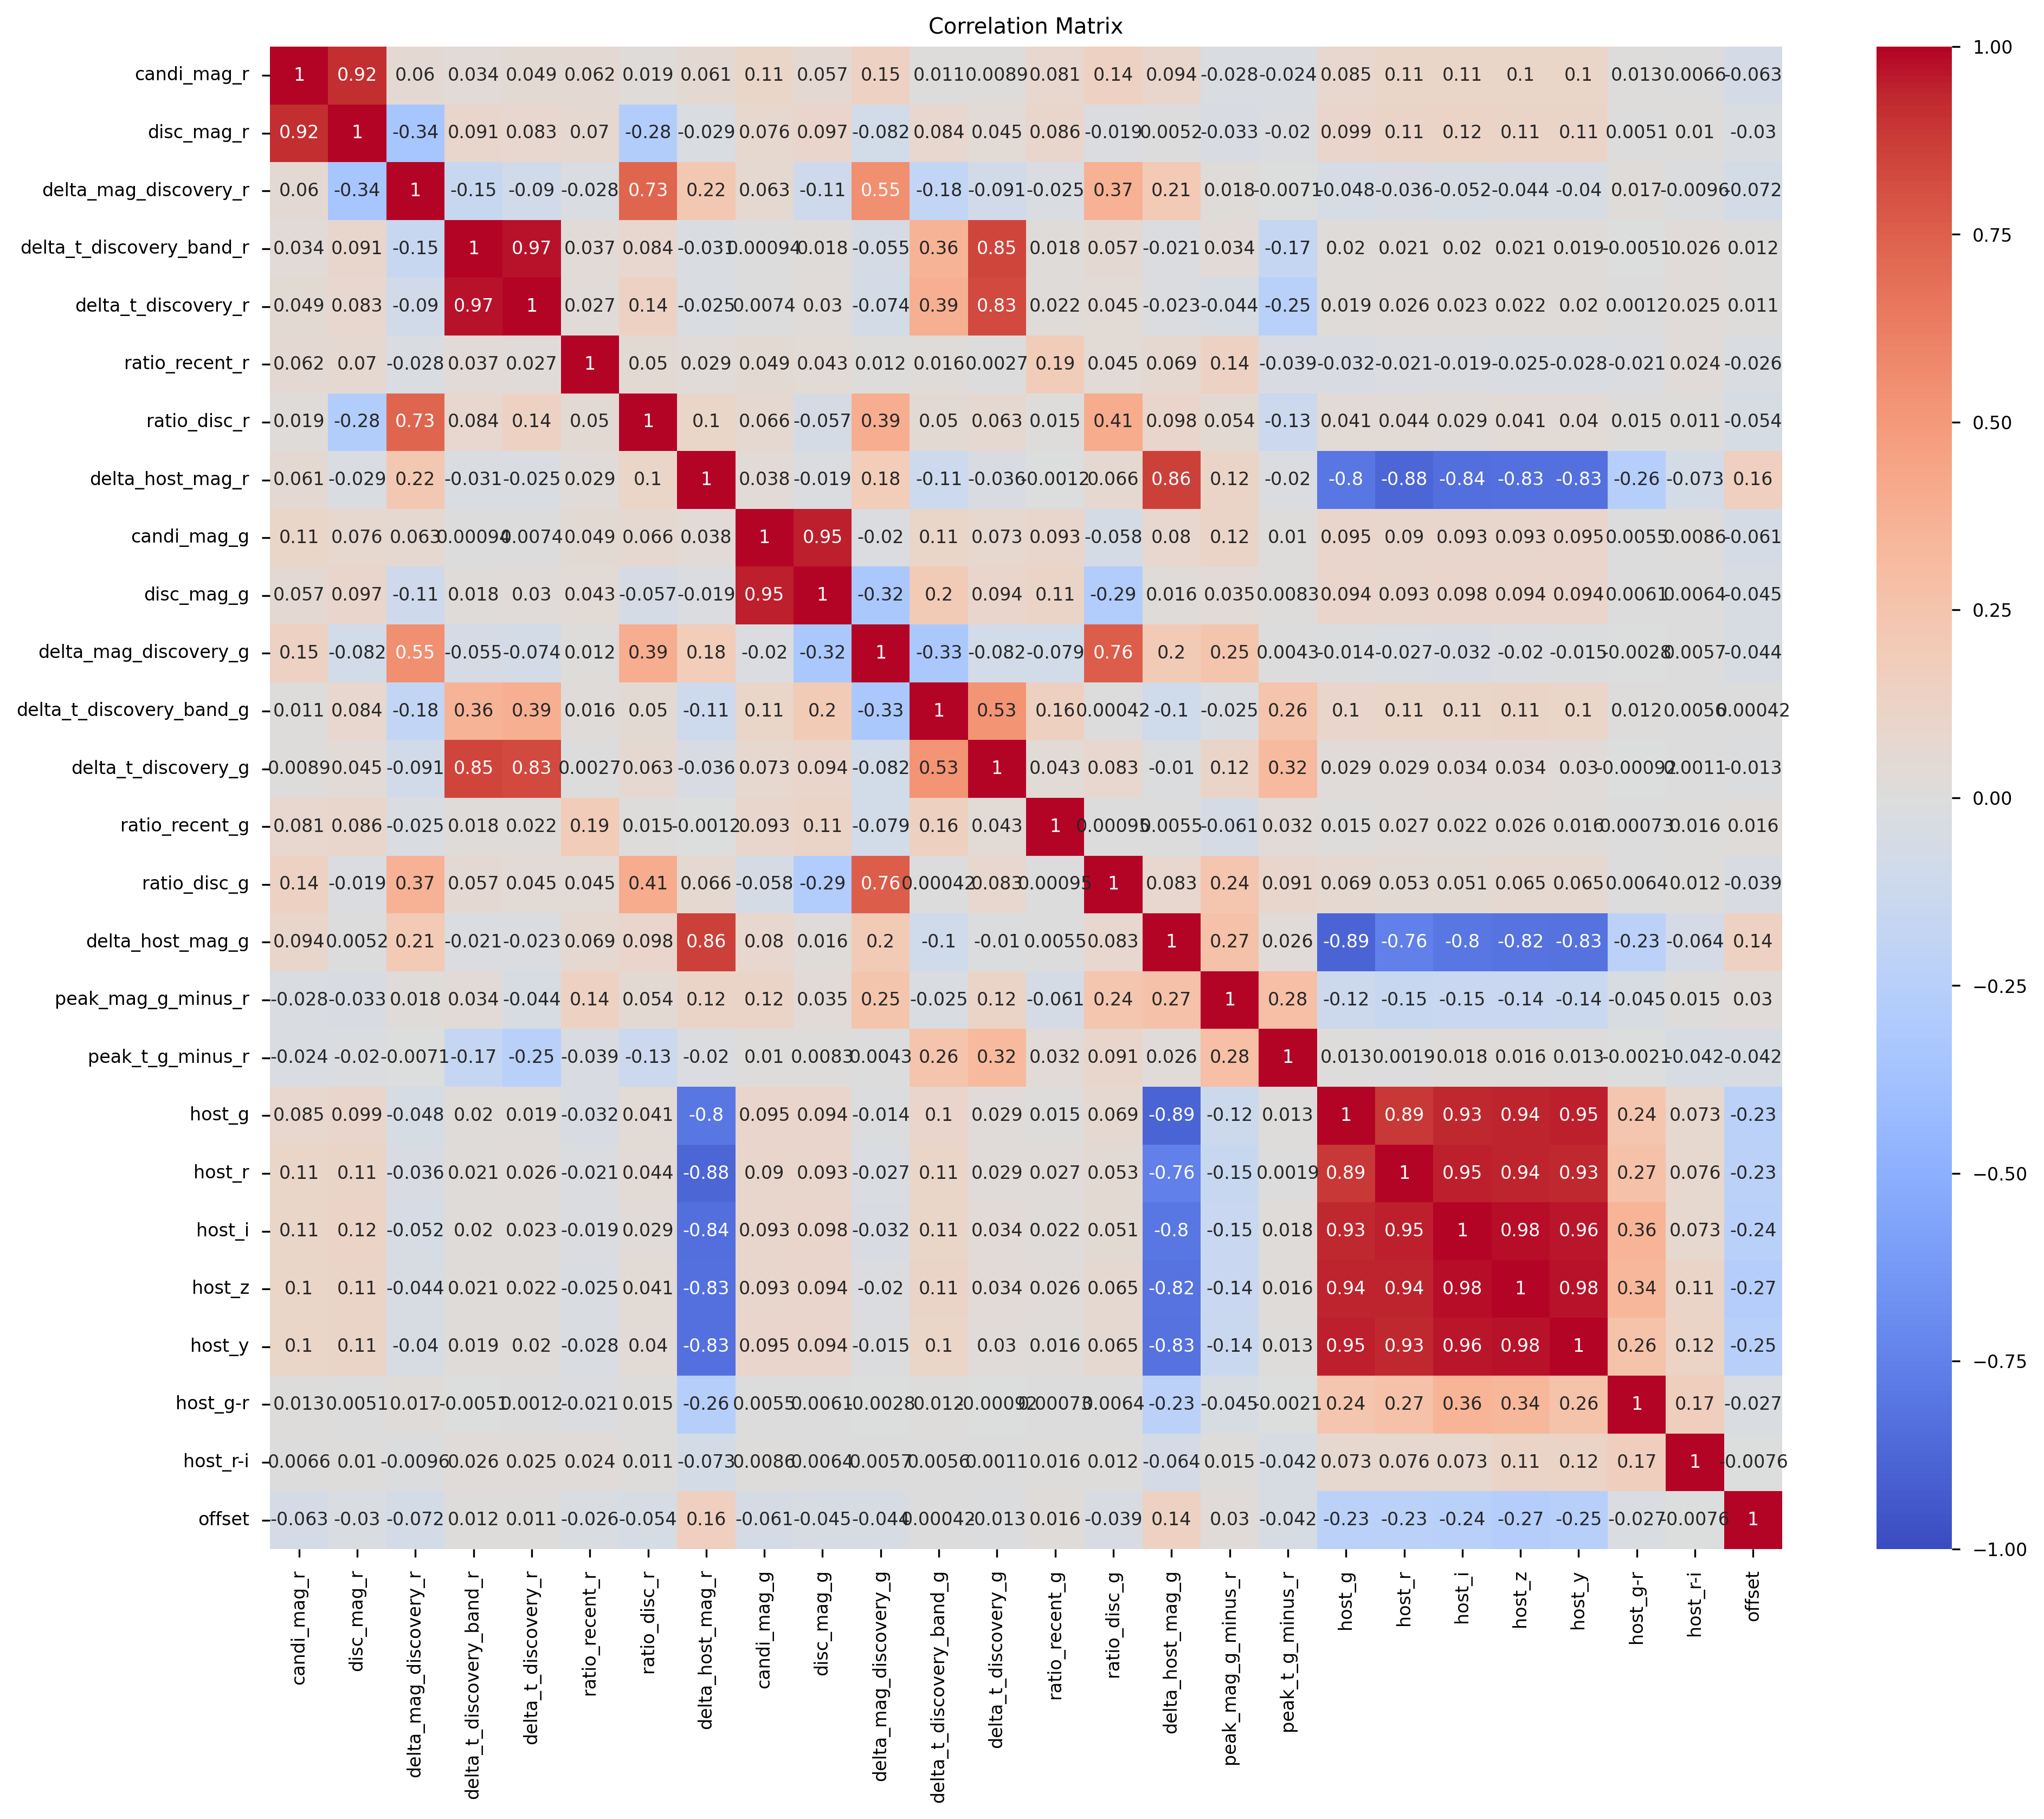

In [24]:
import seaborn as sns
df = pd.DataFrame(metaset, columns=feature_names)
correlation_matrix = df.corr()

# Plot the heatmap2
plt.figure(figsize=(15, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1,annot_kws={"size": 8})
plt.title('Correlation Matrix')
plt.show()

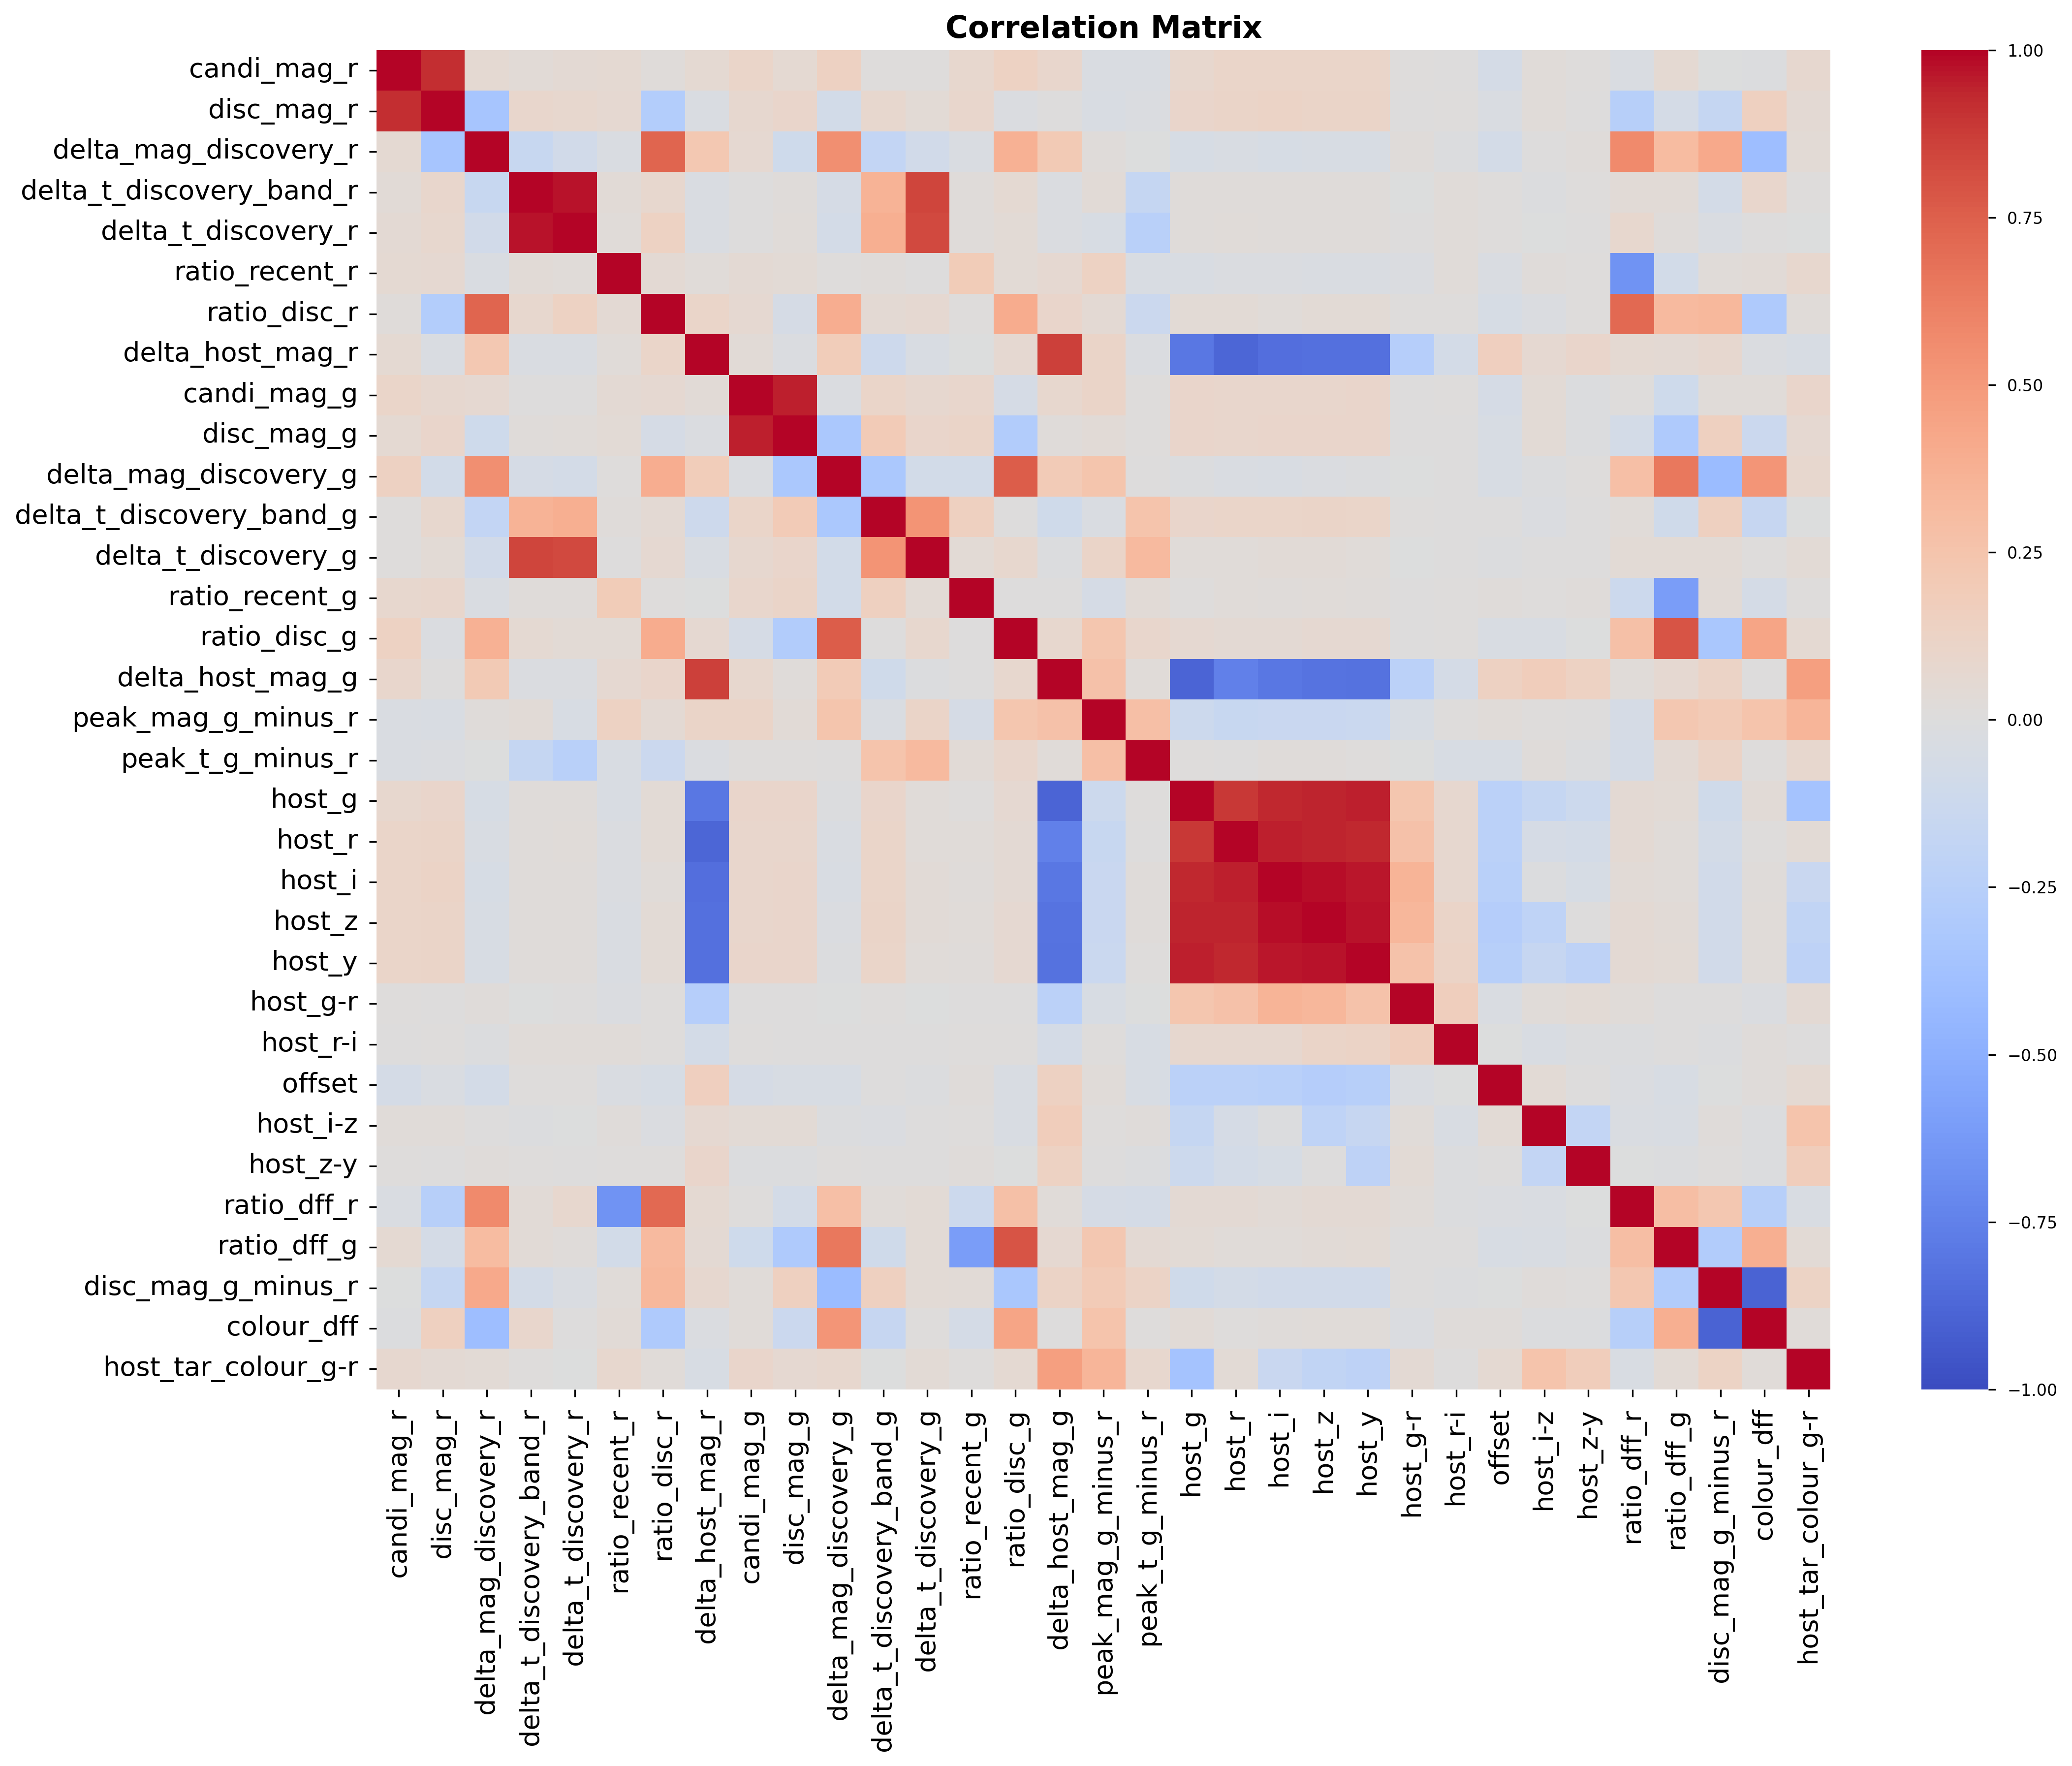

In [25]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


plt.style.use('seaborn-v0_8-paper')
plt.rcParams.update({
    'font.serif': ['Times New Roman'],
    'font.size': 8,
    'axes.labelsize': 8,
    'axes.labelweight': 'bold',
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'legend.title_fontsize': 8,
    'figure.dpi': 300,
    'figure.autolayout': False  # We'll handle layout manually
})
df = pd.DataFrame(metaset, columns=feature_names)

df['host_i-z'] = df['host_i'] - df['host_z']
df['host_z-y'] = df['host_z'] - df['host_y']
df['ratio_dff_r']  = df['ratio_disc_r'] - df['ratio_recent_r']
df['ratio_dff_g']  = df['ratio_disc_g'] - df['ratio_recent_g']
df['disc_mag_g_minus_r'] = df.apply(lambda row: 0 if row['disc_mag_g'] == 0 or row['disc_mag_r'] == 0 else row['disc_mag_g'] - row['disc_mag_r'], axis=1)
df['colour_dff'] = df.apply(lambda row: 0 if row['peak_mag_g_minus_r'] == 0 or row['disc_mag_g_minus_r'] == 0 else row['peak_mag_g_minus_r'] - row['disc_mag_g_minus_r'], axis=1)
df['host_tar_colour_g-r'] = df['delta_host_mag_g'] - df['delta_host_mag_r']
# df_cm = df.drop(['ratio_recent_r', 'ratio_recent_g', 'delta_t_discovery_band_r', 'delta_t_discovery_band_g'], axis = 1)
df_cm = df.copy()
# Calculate the correlation matrix
correlation_matrix = df_cm.corr()

# Plot the heatmap2
plt.figure(figsize=(15, 12))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', vmin=-1, vmax=1,annot_kws={"size": 8})
plt.title('Correlation Matrix', fontsize = 15, fontweight = 'bold')
plt.xticks(fontsize = 13)
plt.yticks(fontsize = 13)
plt.tight_layout()
# plt.show()
plt.savefig('../plots/feature_upgrade_correlation.pdf')

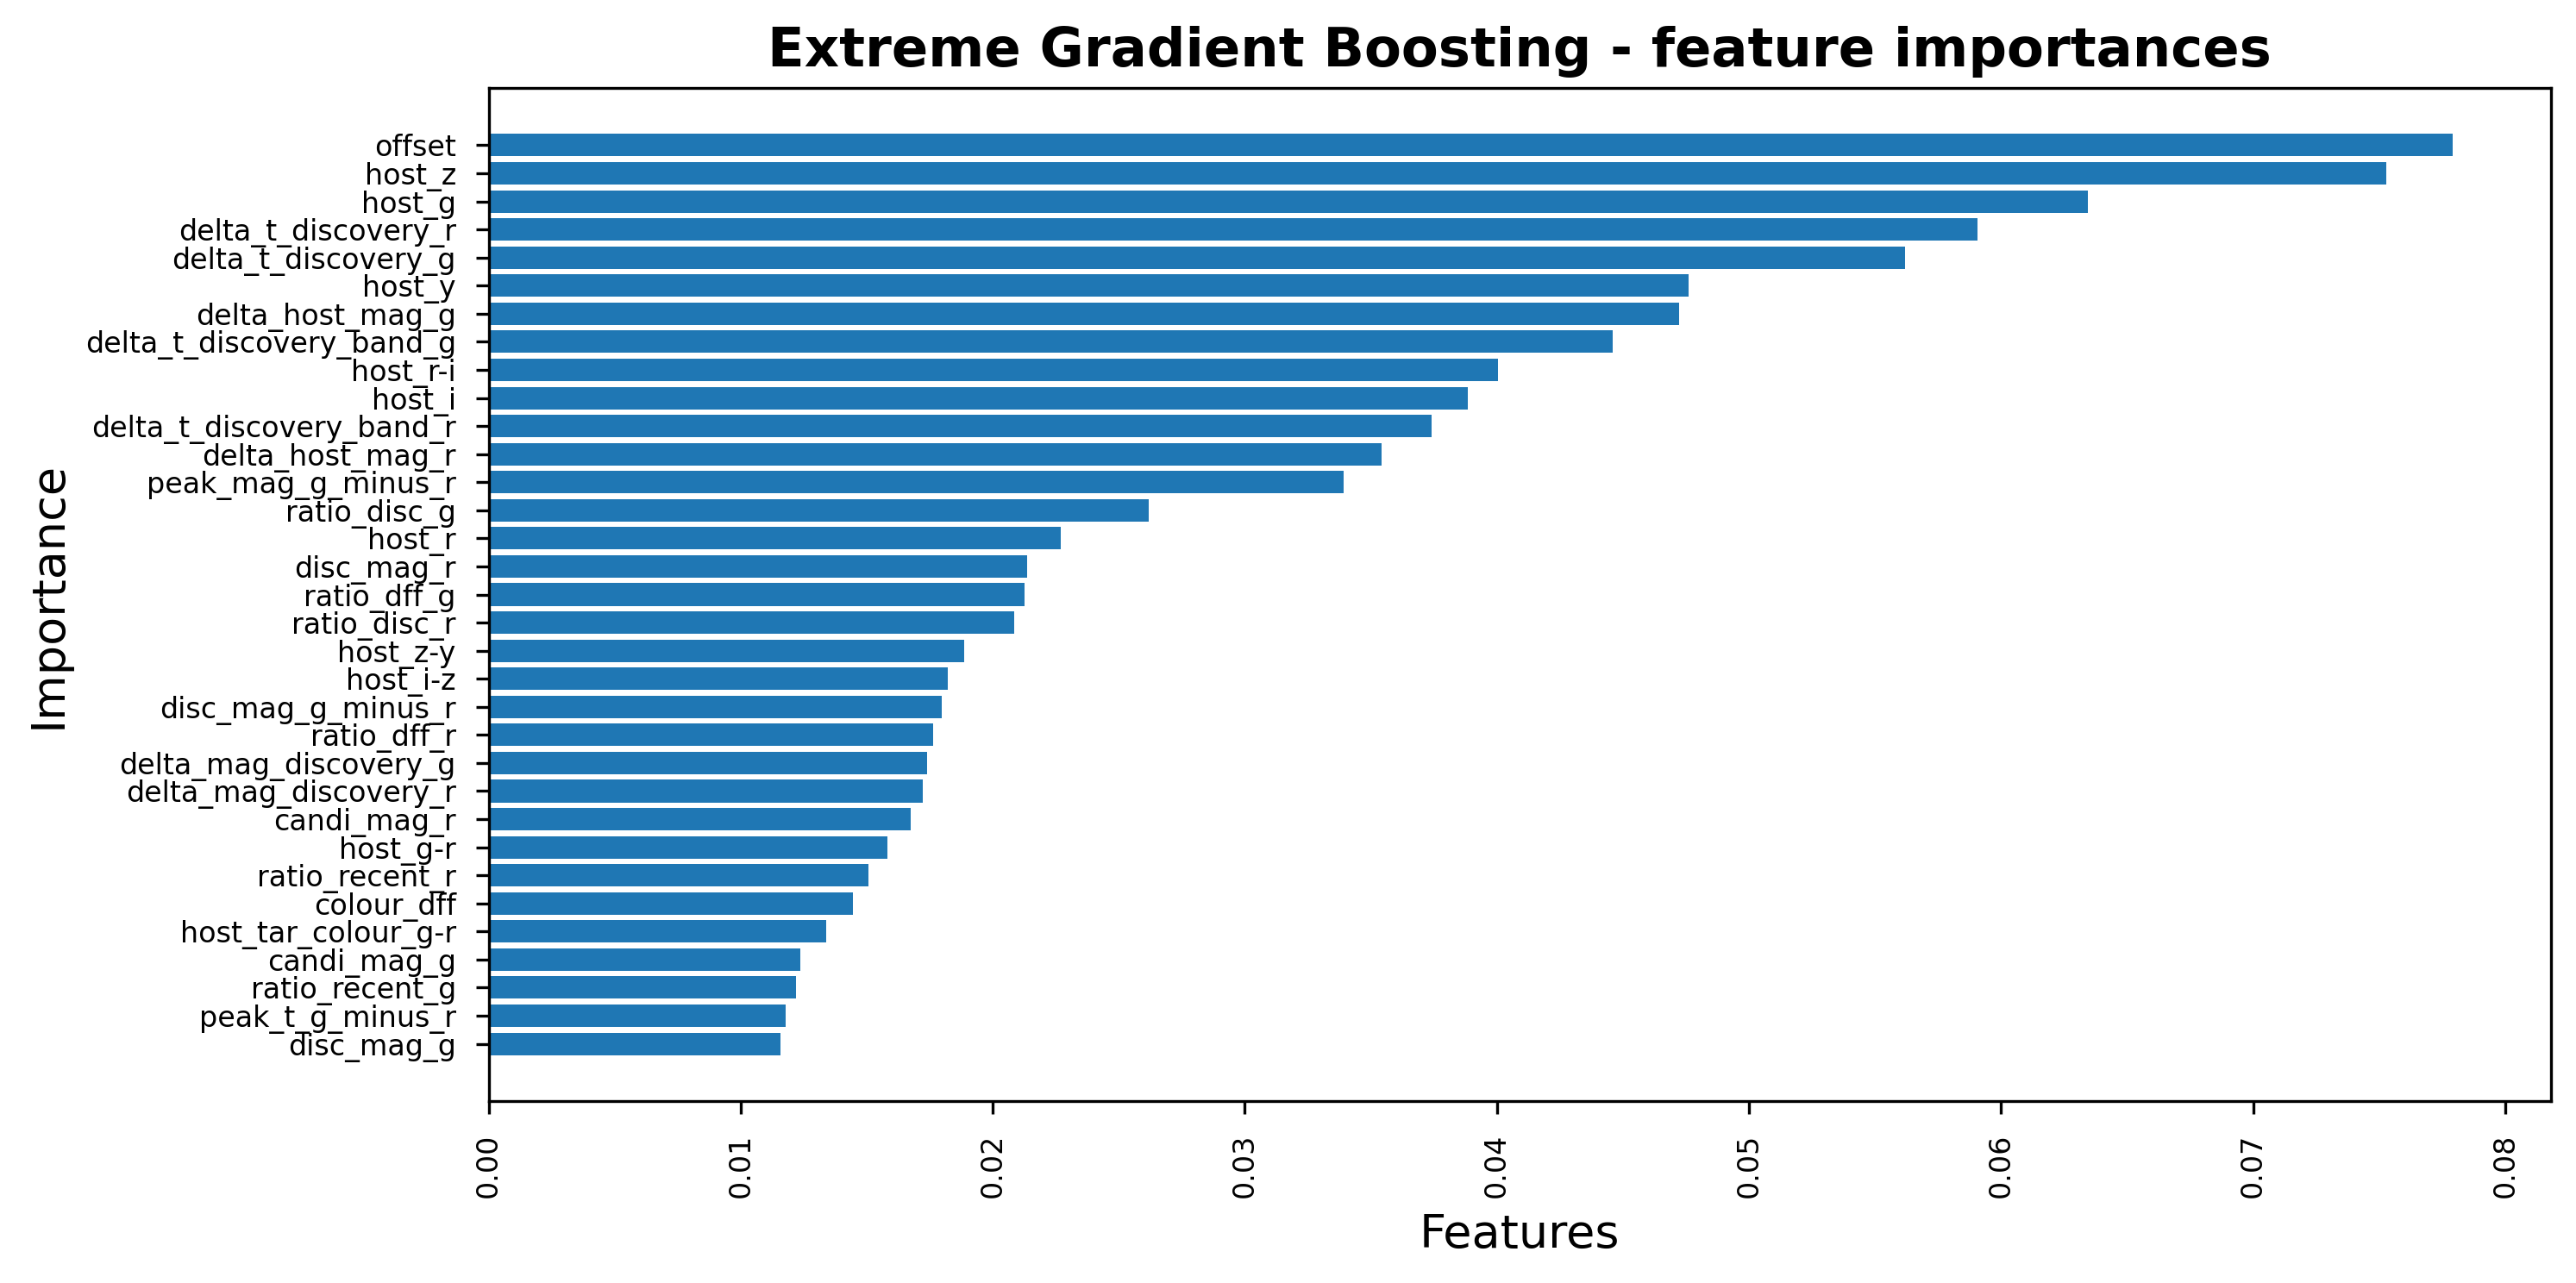

In [26]:
import xgboost as xgb
from xgboost import plot_importance

best_xgb_params = {'subsample': 0.8, 'n_estimators': 200, 'min_child_weight': 2, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 0.6}
xgb_model= xgb.XGBClassifier(**best_xgb_params)
# xgb_model = xgb.XGBClassifier()
xgb_model.fit(df_cm, labels, sample_weight = sample_weights)
feature_names = df_cm.columns

importances = xgb_model.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=True)
plt.figure(figsize=(10, 5))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Features', fontsize = 13, fontweight = 'normal')
plt.ylabel('Importance', fontsize = 13, fontweight = 'normal')
plt.title('Extreme Gradient Boosting - feature importances', fontsize = 15, fontweight = 'bold')
plt.xticks(rotation=90)
plt.tight_layout()
# plt.show()
plt.savefig('../plots/feature_upgrade_xgb.pdf')

